# Student-Marks-Prediction-Using-simple_Linear-Regression

## Objective
- Predict student marks based on study hours.
- Help a coaching institute estimate student performance using historical data.



## Problem Statement
- Manual prediction of student performance is difficult.
- Build a Machine Learning model to automate the prediction process.


In [2]:
# Numerical computing library (arrays, mathematical operations)
import numpy as np

# Library for data visualization and plotting graphs
import matplotlib.pyplot as plt
import seaborn as sns
# Library for data manipulation and analysis (DataFrame)
import pandas as pd


In [3]:
# Read the CSV file and store it in a Pandas DataFrame
dataset = pd.read_csv(r"C:\Users\kunal\Downloads\student_info.csv")

# Display the dataset
dataset

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


In [4]:
# Display the first 5 rows of the dataset
dataset.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [5]:
dataset.tail()

,study_hours,student_marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [6]:
# Display concise information about the DataFrame
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [7]:
# Default: Summary statistics only for numerical columns
dataset.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


In [8]:
# Display the number of rows and columns
dataset.shape

(200, 2)

In [9]:
# Display all column names
dataset.columns

Index(['study_hours', 'student_marks'], dtype='object')

In [10]:
# Count missing values in each column
dataset.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [11]:
# Check if there are any missing values
dataset.isnull().any()

study_hours       True
student_marks    False
dtype: bool

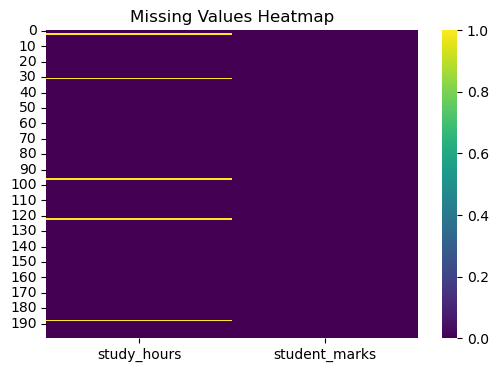

In [12]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(dataset.isnull(), cbar=True, cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

In [13]:


# Remove all columns that contain at least one missing (NaN) value
dataset = dataset.dropna(axis=0)

# Display the updated DataFrame
dataset


,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
3,5.67,71.82
4,8.67,84.19
5,7.55,81.18
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


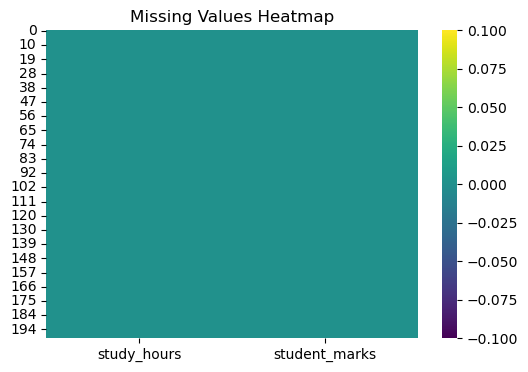

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(dataset.isnull(), cbar=True, cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

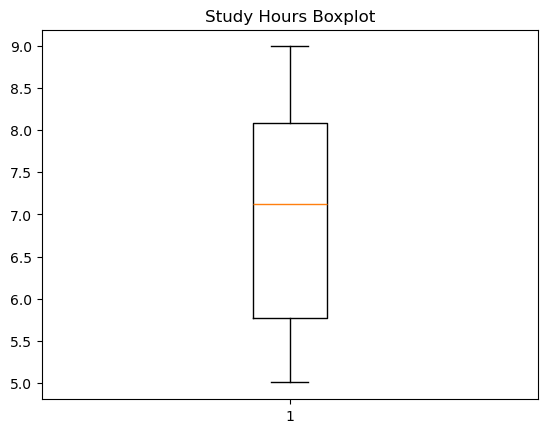

In [15]:
# Boxplot for study_hours
plt.boxplot(dataset["study_hours"])
plt.title("Study Hours Boxplot")
plt.show()

In [16]:
# First Quartile (25%)
Q1 = dataset["study_hours"].quantile(0.25)

# Third Quartile (75%)
Q3 = dataset["study_hours"].quantile(0.75)

# Inter Quartile Range
IQR = Q3 - Q1

# Lower Limit
lower_limit = Q1 - 1.5 * IQR

# Upper Limit
upper_limit = Q3 + 1.5 * IQR

print(lower_limit)
print(upper_limit)

2.3099999999999996
11.55


In [17]:
outliers = dataset[
    (dataset["study_hours"] < lower_limit) |
    (dataset["study_hours"] > upper_limit)
]

outliers

,study_hours,student_marks


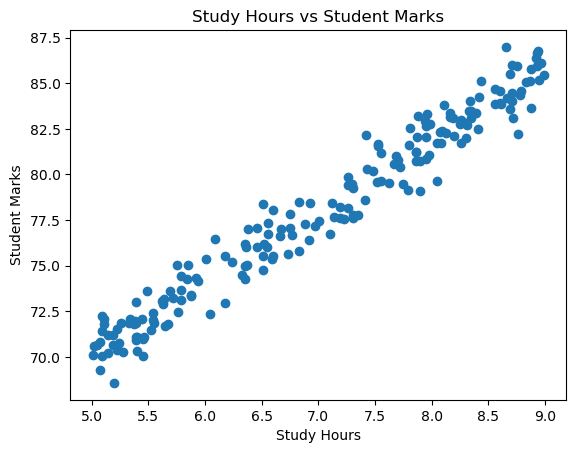

In [18]:


# Create scatter plot
plt.scatter(dataset["study_hours"], dataset["student_marks"])

# Add title
plt.title("Study Hours vs Student Marks")

# X-axis label
plt.xlabel("Study Hours")

# Y-axis label
plt.ylabel("Student Marks")

# Display the graph
plt.show()

In [19]:
# Calculate correlation between numerical columns
dataset.corr()

,study_hours,student_marks
study_hours,1.000000,0.979919
student_marks,0.979919,1.000000


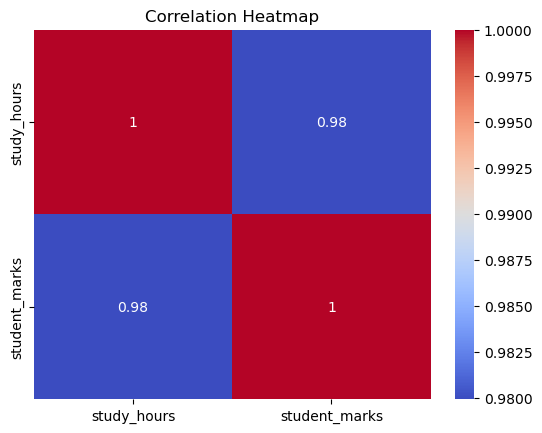

In [20]:
# Plot correlation heatmap
sns.heatmap(dataset.corr(), annot=True, cmap="coolwarm")

# Add title
plt.title("Correlation Heatmap")

# Display graph
plt.show()

In [21]:
dataset.mean()

study_hours       6.995949
student_marks    77.961231
dtype: float64

In [22]:
x = dataset.iloc[:, : -1]
y = dataset.iloc[:, -1]


In [23]:
from sklearn.model_selection import train_test_split

In [24]:
# Split the dataset into 80% training data and 20% testing data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=0)

In [25]:
# Create a Linear Regression model
model = LinearRegression()

In [26]:
# Train the Linear Regression model using the training data
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
# Predict the target values for the test data
y_pred = model.predict(x_test)
y_pred

array([72.66609379, 81.45824996, 78.35969272, 71.77525859, 71.73652662,
       84.59553917, 70.49710373, 75.57099121, 70.65203159, 80.56741476,
       70.96188731, 76.69421821, 75.37733138, 71.69779466, 71.73652662,
       82.03922945, 78.51462059, 75.45479531, 78.01110503, 85.52510634,
       71.73652662, 73.28580524, 84.16948755, 82.62020893, 71.96891841,
       85.44764241, 81.65190979, 70.96188731, 78.97940417, 70.26471193,
       73.51819703, 81.3033221 , 70.49710373, 81.38078603, 80.10263117,
       76.65548624, 84.40187934, 70.3034439 , 81.34205407])

In [28]:

# Compare Actual vs Predicted
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison = comparison.reset_index(drop=True)
comparison = comparison.round(3)

print(comparison)

    Actual  Predicted
0    72.87     72.666
1    80.76     81.458
2    76.76     78.360
3    70.34     71.775
4    71.11     71.737
5    85.98     84.596
6    70.79     70.497
7    77.01     75.571
8    72.08     70.652
9    80.58     80.567
10   70.66     70.962
11   76.99     76.694
12   74.49     75.377
13   71.94     71.698
14   73.02     71.737
15   79.63     82.039
16   77.65     78.515
17   76.19     75.455
18   77.46     78.011
19   85.15     85.525
20   70.90     71.737
21   73.64     73.286
22   84.58     84.169
23   82.10     82.620
24   70.06     71.969
25   86.65     85.448
26   80.86     81.652
27   71.18     70.962
28   78.17     78.979
29   70.11     70.265
30   75.02     73.518
31   80.72     81.303
32   69.27     70.497
33   83.23     81.381
34   81.18     80.103
35   76.63     76.655
36   86.99     84.402
37   70.58     70.303
38   82.04     81.342


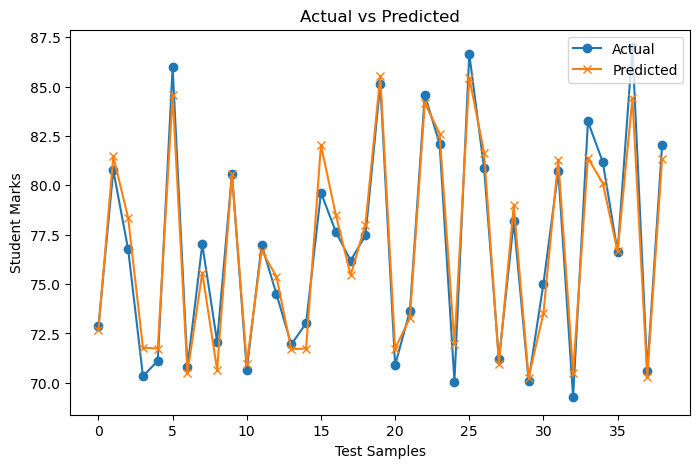

In [29]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values, label="Actual", marker="o")
plt.plot(y_pred, label="Predicted", marker="x")

plt.title("Actual vs Predicted")
plt.xlabel("Test Samples")
plt.ylabel("Student Marks")
plt.legend()

plt.show()

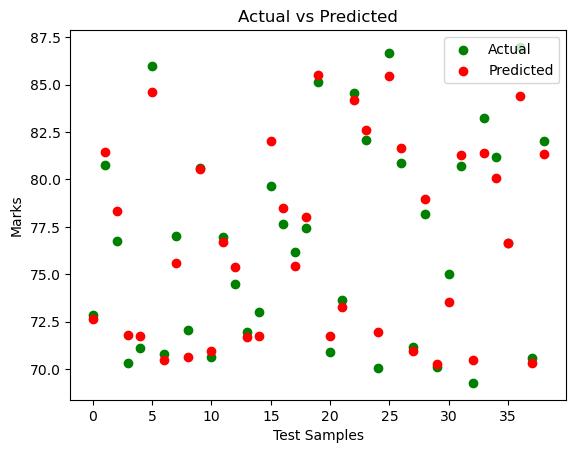

In [30]:


plt.scatter(range(len(y_test)), y_test, color="green", label="Actual")
plt.scatter(range(len(y_pred)), y_pred, color="red", label="Predicted")



plt.title("Actual vs Predicted")
plt.xlabel("Test Samples")
plt.ylabel("Marks")
plt.legend(loc="upper right")
plt.show()

In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("-" * 35)
print(f"MAE      : {mae:.3f}")
print(f"MSE      : {mse:.3f}")
print(f"RMSE     : {rmse:.3f}")
print(f"R² Score : {r2:.3f}")

Model Evaluation Metrics
-----------------------------------
MAE      : 0.874
MSE      : 1.167
RMSE     : 1.080
R² Score : 0.959


In [32]:
# Calculate Residuals
residuals = y_test - y_pred

# Display Actual, Predicted and Residual
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Residual": residuals
})

comparison = comparison.round(3).sort_index()
print(comparison)

     Actual  Predicted  Residual
5     81.18     80.103     1.077
6     76.99     76.694     0.296
8     70.66     70.962    -0.302
13    80.76     81.458    -0.698
19    80.58     80.567     0.013
23    75.02     73.518     1.502
35    76.76     78.360    -1.600
39    83.23     81.381     1.849
46    77.46     78.011    -0.551
47    70.11     70.265    -0.155
57    86.65     85.448     1.202
58    70.90     71.737    -0.837
62    76.19     75.455     0.735
65    70.06     71.969    -1.909
68    69.27     70.497    -1.227
76    72.08     70.652     1.428
82    76.63     76.655    -0.025
85    72.87     72.666     0.204
91    82.10     82.620    -0.520
109   70.58     70.303     0.277
113   80.86     81.652    -0.792
116   70.34     71.775    -1.435
127   77.65     78.515    -0.865
128   77.01     75.571     1.439
129   74.49     75.377    -0.887
138   85.98     84.596     1.384
140   84.58     84.169     0.411
145   85.15     85.525    -0.375
159   80.72     81.303    -0.583
164   82.0

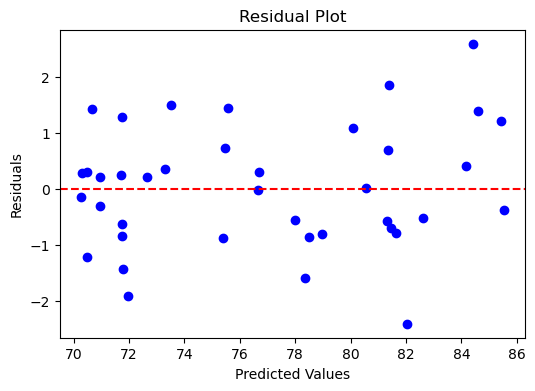

In [33]:


plt.figure(figsize=(6,4))

plt.scatter(y_pred, residuals, color="blue")

plt.axhline(y=0, color="red", linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

In [34]:
# Checking the Model Coefficient

print("Coefficient (Slope):", model.coef_)

Coefficient (Slope): [3.87319655]


In [35]:
# Checking the Model Intercept

print("Intercept:", model.intercept_)

Intercept: 50.859997214018385


## 11. Assumptions

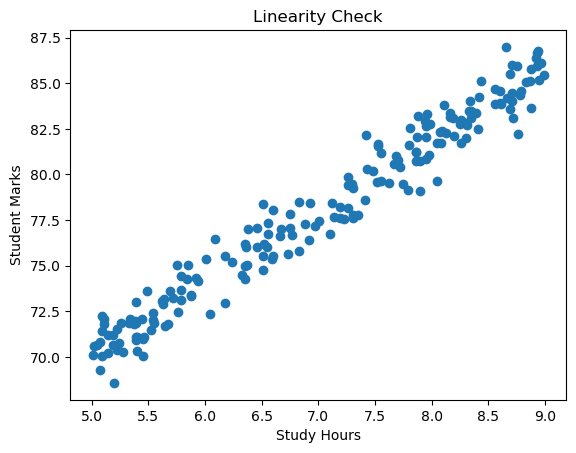

Durbin-Watson: 1.913


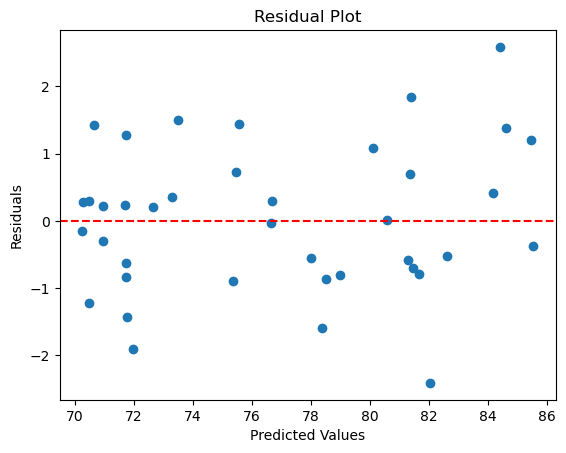

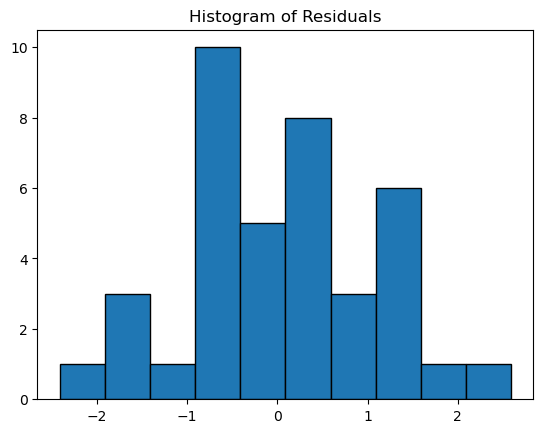

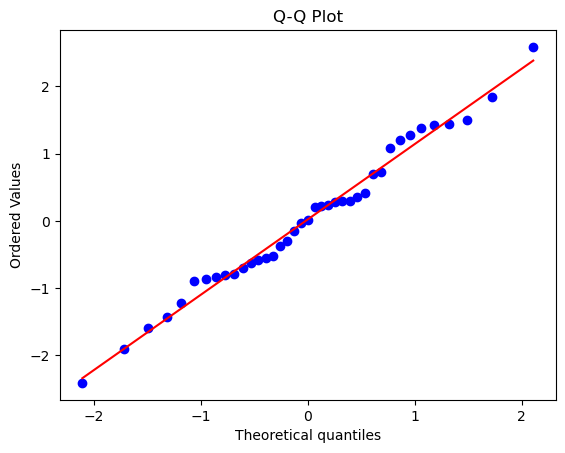

In [36]:
# Import required libraries
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.stattools import durbin_watson

# Calculate residuals
residuals = y_test - y_pred

# -------------------------------
# 1. Linearity
# -------------------------------
plt.scatter(x, y)
plt.title("Linearity Check")
plt.xlabel("Study Hours")
plt.ylabel("Student Marks")
plt.show()

# -------------------------------
# 2. Independence of Errors
# -------------------------------
dw = durbin_watson(residuals)
print("Durbin-Watson:", round(dw, 3))

# -------------------------------
# 3. Homoscedasticity
# -------------------------------
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

# -------------------------------
# 4. Normality of Residuals
# -------------------------------
plt.hist(residuals, bins=10, edgecolor="black")
plt.title("Histogram of Residuals")
plt.show()

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [50]:
# Display regression equation
print(f"Student Marks = ({model.coef_[0]:.3f} × Study Hours) + {model.intercept_:.3f}")

Student Marks = (3.873 × Study Hours) + 50.860


In [51]:
# New input
new_data = pd.DataFrame({"study_hours": [6]})

# Predict marks
prediction = model.predict(new_data)

# Display prediction
print("Predicted Marks:", round(prediction[0], 2))

Predicted Marks: 74.1


In [40]:
import os

print(os.getcwd())

C:\Users\kunal\Downloads


In [42]:
import os

os.path.exists("simple_linear_model.joblib")

False

In [43]:
import joblib

joblib.dump(model, "simple_linear_model.joblib")

print("Model Saved Successfully")

Model Saved Successfully


In [44]:
import os

os.path.exists("simple_linear_model.joblib")

True

In [45]:
import joblib

loaded_model = joblib.load("simple_linear_model.joblib")

print("Model Loaded Successfully")

Model Loaded Successfully


In [46]:
study_hours = float(input("Enter Study Hours: "))

new_data = pd.DataFrame({
    "study_hours": [study_hours]
})

prediction = loaded_model.predict(new_data)

print("Predicted Marks:", round(prediction[0], 2))

Enter Study Hours:  12


Predicted Marks: 97.34


## Conclusion
- Successfully developed a Simple Linear Regression model.
- Predicted student marks using study hours.
- Evaluated model performance using multiple metrics.
- Verified regression assumptions.
- Saved and loaded the trained model for future predictions.